In [9]:
%pip install torch torchvision matplotlib scikit-learn numpy pandas seaborn

Note: you may need to restart the kernel to use updated packages.


In [10]:
#!/usr/bin/env python3
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd
import seaborn as sns

In [11]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --------------
# Parameters
# --------------
IMG_SIZE = 28       # FashionMNIST images are 28x28
NUM_CLASSES = 10
BATCH_SIZE = 64
NUM_EPOCHS = 10     
LEARNING_RATE = 0.001
VALID_SPLIT = 0.2

Using device: cpu


In [12]:
# Baseline transform: convert image to tensor and scale pixels to [0,1]
baseline_transform = transforms.Compose([
    transforms.ToTensor()
])

# Improved model transform: include data augmentation
improved_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

# Download the FashionMNIST training and test datasets.
train_val_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=baseline_transform
)

# For the improved model, we apply data augmentation on the training data.
train_val_dataset_aug = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=improved_transform
)

# Load test dataset with baseline transform (no augmentation for test)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=baseline_transform
)

# Split the train_val_dataset into training and validation sets
total_train = len(train_val_dataset)
train_size = int((1 - VALID_SPLIT) * total_train)
val_size = total_train - train_size
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

# For the improved model, do a similar split (or reuse the same indices)
train_dataset_aug, _ = random_split(train_val_dataset_aug, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
train_loader_improved = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)


In [13]:

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))       # (N, 32, 28, 28)
        x = self.relu(self.conv2(x))       # (N, 64, 28, 28)
        x = self.pool(x)                   # (N, 64, 14, 14)
        x = x.view(x.size(0), -1)          # Flatten: (N, 64*14*14)
        x = self.relu(self.fc1(x))         # (N, 128)
        x = self.fc2(x)                    # (N, num_classes)
        return x

class ImprovedCNN(nn.Module):
    """
    An improved CNN model with extra layers, dropout, and batch normalization.
    Additionally, training uses data augmentation.
    """
    def __init__(self, num_classes=10):
        super(ImprovedCNN, self).__init__()
        # First convolution block
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        # Second convolution block
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        # Third convolution block
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        # Dropout to prevent overfitting
        self.dropout = nn.Dropout(0.5)
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))   # (N, 32, 28, 28)
        x = self.relu(self.bn2(self.conv2(x)))   # (N, 64, 28, 28)
        x = self.relu(self.bn3(self.conv3(x)))   # (N, 64, 28, 28)
        x = self.pool(x)                         # (N, 64, 14, 14)
        x = self.dropout(x)                      # apply dropout
        x = x.view(x.size(0), -1)                # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [14]:

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))       # (N, 32, 28, 28)
        x = self.relu(self.conv2(x))       # (N, 64, 28, 28)
        x = self.pool(x)                   # (N, 64, 14, 14)
        x = x.view(x.size(0), -1)          # Flatten: (N, 64*14*14)
        x = self.relu(self.fc1(x))         # (N, 128)
        x = self.fc2(x)                    # (N, num_classes)
        return x

class ImprovedCNN(nn.Module):
    """
    An improved CNN model with extra layers, dropout, and batch normalization.
    Additionally, training uses data augmentation.
    """
    def __init__(self, num_classes=10):
        super(ImprovedCNN, self).__init__()
        # First convolution block
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        # Second convolution block
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        # Third convolution block
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        # Dropout to prevent overfitting
        self.dropout = nn.Dropout(0.5)
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))   # (N, 32, 28, 28)
        x = self.relu(self.bn2(self.conv2(x)))     # (N, 64, 28, 28)
        x = self.relu(self.bn3(self.conv3(x)))     # (N, 64, 28, 28)
        x = self.pool(x)                           # (N, 64, 14, 14)
        x = self.dropout(x)                        # apply dropout
        x = x.view(x.size(0), -1)                  # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [15]:
def train_model(model, train_loader, val_loader, num_epochs, criterion, optimizer, device):
    model.to(device)
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation phase
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * images.size(0)
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")
    return train_losses, val_losses

def test_model(model, test_loader, device):
    model.to(device)
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100.0 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy, all_labels, all_preds

def plot_loss_curves(train_losses, val_losses, title="Loss Curves"):
    plt.figure(figsize=(8,6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# New Section: Compute and Plot a Table for Accuracy, Precision, Recall, F1-Score
def evaluate_and_plot_metrics(model, test_loader, device, model_name):
    from sklearn.metrics import classification_report
    # Get predictions
    accuracy, y_true, y_pred = test_model(model, test_loader, device)
    
    # Compute classification report as dictionary
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    # We use weighted averages for multiclass metrics
    metrics = {
        "Accuracy": accuracy / 100.0,  # converting to fraction for plotting consistency
        "Precision": report_dict["weighted avg"]["precision"],
        "Recall": report_dict["weighted avg"]["recall"],
        "F1-Score": report_dict["weighted avg"]["f1-score"]
    }
    
    # Create a DataFrame for easier display and plotting
    df = pd.DataFrame(metrics, index=[model_name])
    print(f"\nClassification Metrics for {model_name}:")
    print(df)
    
    # Plot the metrics as a bar chart
    df.plot(kind="bar", figsize=(6,4), ylim=(0,1), title=f"Performance Metrics for {model_name}")
    plt.xlabel("Model")
    plt.ylabel("Metric Value")
    plt.show()
    
    return metrics

Training Baseline Model:
Epoch 1/10 - Train Loss: 0.4209, Val Loss: 0.2792
Epoch 2/10 - Train Loss: 0.2520, Val Loss: 0.2318
Epoch 3/10 - Train Loss: 0.2004, Val Loss: 0.2144
Epoch 4/10 - Train Loss: 0.1603, Val Loss: 0.2365
Epoch 5/10 - Train Loss: 0.1290, Val Loss: 0.2078
Epoch 6/10 - Train Loss: 0.1004, Val Loss: 0.2241
Epoch 7/10 - Train Loss: 0.0769, Val Loss: 0.2508
Epoch 8/10 - Train Loss: 0.0563, Val Loss: 0.2746
Epoch 9/10 - Train Loss: 0.0424, Val Loss: 0.3172
Epoch 10/10 - Train Loss: 0.0366, Val Loss: 0.3069
Evaluating Baseline Model on Test Set:
Test Accuracy: 91.53%


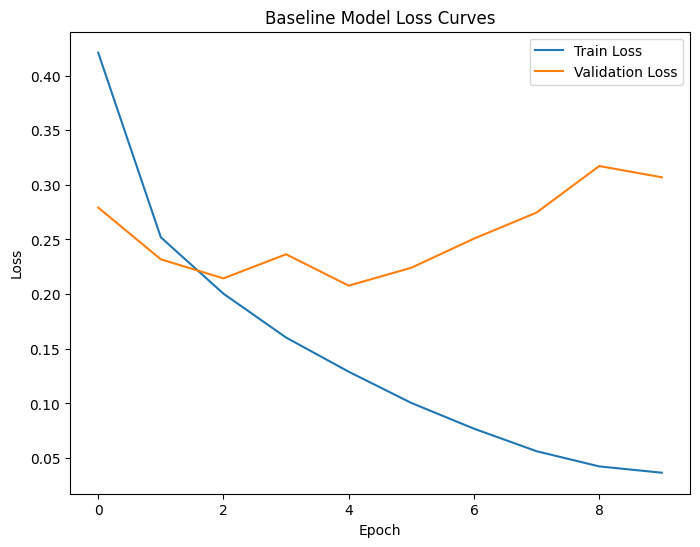

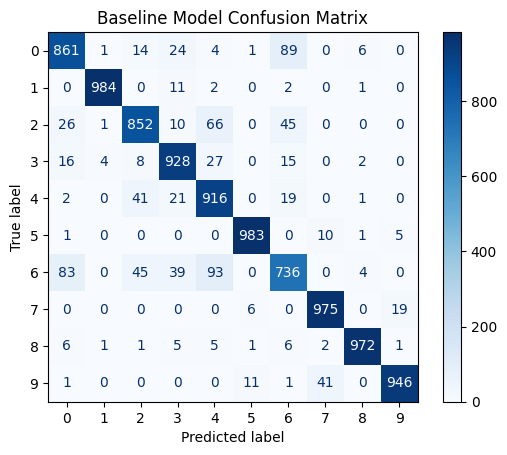

Test Accuracy: 91.53%

Classification Metrics for Baseline CNN:
              Accuracy  Precision  Recall  F1-Score
Baseline CNN    0.9153   0.915567  0.9153  0.914914


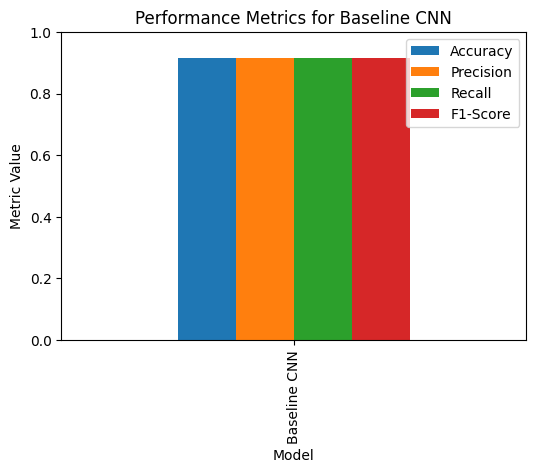


Training Improved Model (with modifications: dropout, batch normalization, and data augmentation):
Epoch 1/10 - Train Loss: 0.4670, Val Loss: 0.2918
Epoch 2/10 - Train Loss: 0.3292, Val Loss: 0.2366
Epoch 3/10 - Train Loss: 0.2901, Val Loss: 0.2344
Epoch 4/10 - Train Loss: 0.2715, Val Loss: 0.2024
Epoch 5/10 - Train Loss: 0.2557, Val Loss: 0.1979
Epoch 6/10 - Train Loss: 0.2399, Val Loss: 0.1838
Epoch 7/10 - Train Loss: 0.2313, Val Loss: 0.1736
Epoch 8/10 - Train Loss: 0.2180, Val Loss: 0.1713
Epoch 9/10 - Train Loss: 0.2143, Val Loss: 0.1611
Epoch 10/10 - Train Loss: 0.2067, Val Loss: 0.1664
Evaluating Improved Model on Test Set:
Test Accuracy: 91.60%


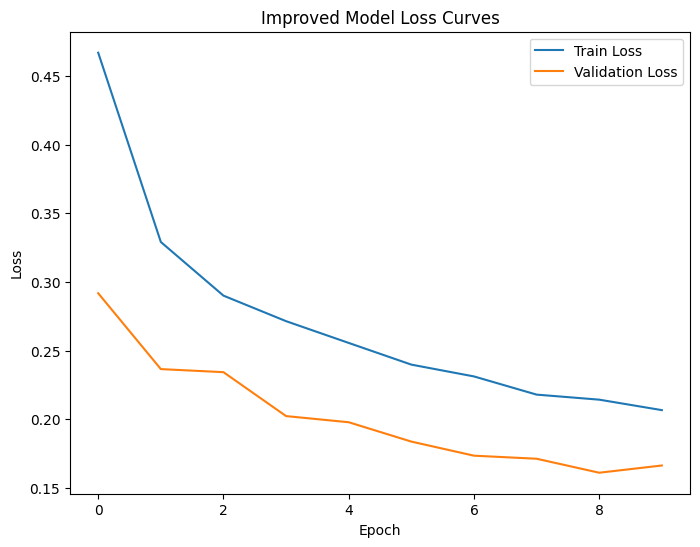

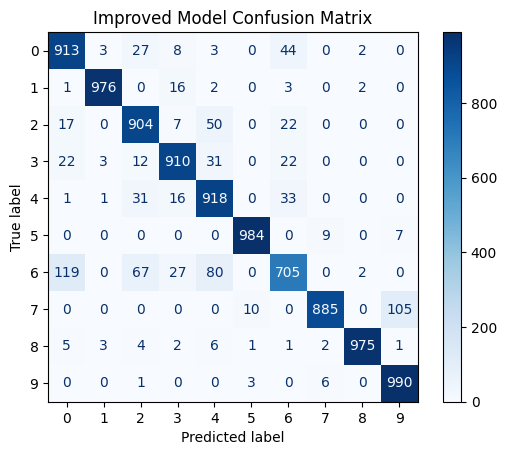

Test Accuracy: 91.60%

Classification Metrics for Improved CNN:
              Accuracy  Precision  Recall  F1-Score
Improved CNN     0.916   0.917412   0.916  0.915211


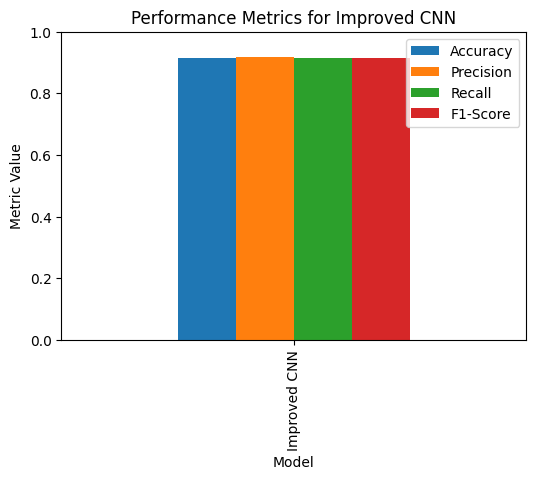


--- Comparison of Models ---
              Accuracy  Precision  Recall  F1-Score
Baseline CNN    0.9153   0.915567  0.9153  0.914914
Improved CNN    0.9160   0.917412  0.9160  0.915211


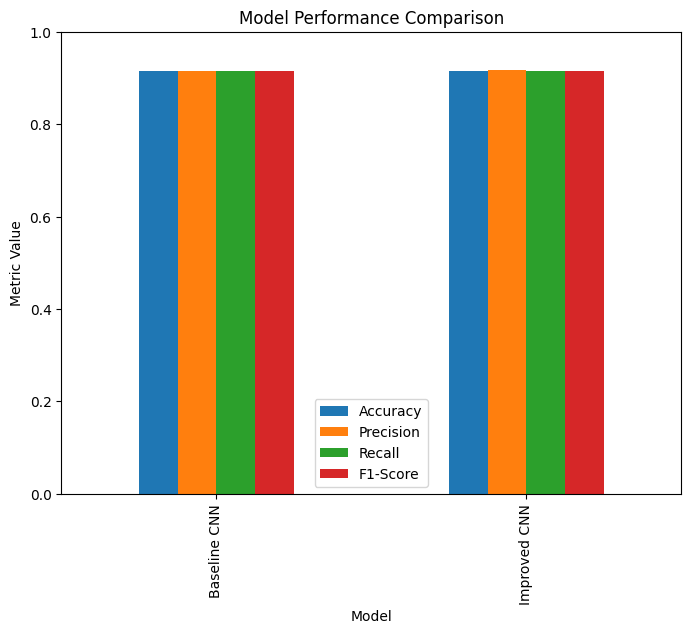


Baseline Model Test Accuracy: 91.53%
Improved Model Test Accuracy: 91.60%


In [16]:
if __name__ == "__main__":
    # Instantiate models
    baseline_model = BaselineCNN(num_classes=NUM_CLASSES)
    improved_model = ImprovedCNN(num_classes=NUM_CLASSES)
    
    # Loss function and optimizers for both models
    criterion = nn.CrossEntropyLoss()
    optimizer_baseline = optim.Adam(baseline_model.parameters(), lr=LEARNING_RATE)
    optimizer_improved = optim.Adam(improved_model.parameters(), lr=LEARNING_RATE)
    
    print("Training Baseline Model:")
    baseline_train_losses, baseline_val_losses = train_model(
        baseline_model, train_loader, val_loader, NUM_EPOCHS, criterion, optimizer_baseline, device
    )
    print("Evaluating Baseline Model on Test Set:")
    baseline_accuracy, baseline_y_true, baseline_y_pred = test_model(baseline_model, test_loader, device)
    plot_loss_curves(baseline_train_losses, baseline_val_losses, title="Baseline Model Loss Curves")
    plot_confusion_matrix(baseline_y_true, baseline_y_pred, title="Baseline Model Confusion Matrix")
    baseline_metrics = evaluate_and_plot_metrics(baseline_model, test_loader, device, model_name="Baseline CNN")
    
    print("\nTraining Improved Model (with modifications: dropout, batch normalization, and data augmentation):")
    improved_train_losses, improved_val_losses = train_model(
        improved_model, train_loader_improved, val_loader, NUM_EPOCHS, criterion, optimizer_improved, device
    )
    print("Evaluating Improved Model on Test Set:")
    improved_accuracy, improved_y_true, improved_y_pred = test_model(improved_model, test_loader, device)
    plot_loss_curves(improved_train_losses, improved_val_losses, title="Improved Model Loss Curves")
    plot_confusion_matrix(improved_y_true, improved_y_pred, title="Improved Model Confusion Matrix")
    improved_metrics = evaluate_and_plot_metrics(improved_model, test_loader, device, model_name="Improved CNN")
    
    # Print comparative results as a table
    comparison_df = pd.DataFrame([baseline_metrics, improved_metrics], index=["Baseline CNN", "Improved CNN"])
    print("\n--- Comparison of Models ---")
    print(comparison_df)
    comparison_df.plot(kind="bar", figsize=(8,6), ylim=(0,1), title="Model Performance Comparison")
    plt.xlabel("Model")
    plt.ylabel("Metric Value")
    plt.show()
    
    print(f"\nBaseline Model Test Accuracy: {baseline_accuracy:.2f}%")
    print(f"Improved Model Test Accuracy: {improved_accuracy:.2f}%")